In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from matplotlib import colors
from matplotlib import transforms
import os
import sys
from pathlib import Path
from paper_style import *
%matplotlib inline

In [2]:
matplotlib.rcParams["text.usetex"] = True
plt.rc('font', family='serif')
NOTEBOOK_DIR = Path.cwd()
INPUTS_DIR = NOTEBOOK_DIR.parent.parent / "inputs"
DATA_DIR = NOTEBOOK_DIR.parent / "Plots"

if str(INPUTS_DIR) not in sys.path:
    sys.path.append(str(INPUTS_DIR))

#import constants as const

In [3]:
data = np.loadtxt(DATA_DIR /"scan_01.dat")

In [4]:
dm21, dm31, s12l, s23l, s13l, deltaCP, Rgamma, kappa_F, A1, A2, C, lamb_eta1_phi, lamb_eta1_sigma, lamb_12_phi, lamb_12_sigma, lamb_eta2_phi, lamb_eta2_sigma, lamb_phi, lamb_phi_sigma, lamb_sigma, mu_12, mu_eta1, mu_eta2, mu_phi, z, vsigma, yuk_abs_11, yuk_abs_12, yuk_abs_21, yuk_abs_22, yuk_abs_31, yuk_abs_32, mh, mHH, mR1, mR2, mI1, mI2, mCH1, mCH2, alpha, theta_c, sigma_SI, fEW, ftree, fscoto, chi, pen_structure, pen_restriction, penalty_total, cost_function = data.T

In [5]:
LZ = 8.78658722623048e-47
XENONnT = 4.484204325419306e-47
DARWIN = 2.67279895071297e-47
ARGO = 8.130408367888161e-48

In [6]:
rN = ftree/fEW
zeta = (2600/vsigma)*np.sin(2*alpha)*(1-(mh**2/mHH**2))
rho = np.cos(2*alpha)**2 + np.sin(2*alpha)**2*(mh**2/mHH**2)
Cfact = 0.389379e-27
mXi = 2600
mN = 0.939
sEW = (4/3.141592653589793)*mN**2*((mXi*mN)/(mXi+mN))**2*fEW**2*Cfact
zXi = 0.5*2600/vsigma
XDD = zXi*np.sin(2*alpha)*(1-(mh**2/mHH**2))

In [7]:
kt_s1 = 0.99 + 0.09
kt_s3 = 0.99 + 3*0.09
kt_i1 = 0.99 - 0.09
kt_i3 = 0.99 - 3*0.09
kb_s1 = 0.89 + 0.1
kb_s3 = 0.89 + 3*0.1
kb_i1 = 0.89 - 0.09
kb_i3 = 0.89 - 3*0.09
kw_s1 = 1 + 0.05
kw_s3 = 1 + 3*0.05
kw_i1 = 1 - 0.05
kw_i3 = 1 - 3*0.05

ckw = 1.03 - 3 * 0.06
ckt = 0.92 - 3 * 0.08
ckb = 0.98 - 3 * 0.12

In [26]:
print(mHH.min())

189.9844


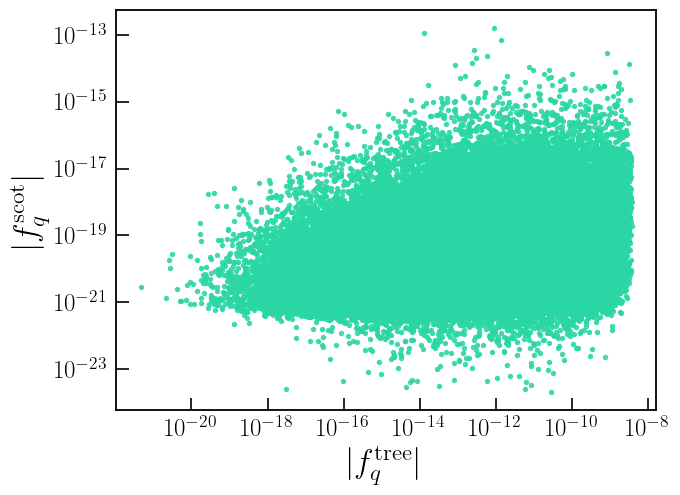

In [10]:
plt.style.use('./paper_style_colorbar.mplstyle')

fig = plt.figure(figsize=(9, 5))
ax_main = fig.add_axes([0.1, 0.1, 0.6, 0.8])
trans_xaxes_ydata = transforms.blended_transform_factory(ax_main.transAxes, ax_main.transData)

x = np.linspace(-100, 100, 10000)
y = np.abs(1 + x)**2

sm = 2.2198e-10

A = ftree/XDD

B = fEW/sm

sc_main = sp_scatter(ax_main, np.abs(ftree), np.abs(fscoto), allow_cond=None, c_theme=c6, x_lab=r'$|f^{\rm tree}_q|$',
                    y_lab=r'$|f^{\rm scot}_q|$', lw=0.0)

#ax_main.plot(x, y, color='red', linewidth=1.1, label=r'$y = |1 + x^2|$')
'''
ax_main.vlines(x=-1, ymin=1e-6, ymax=1e5, color=c1, linestyle='--', linewidth=1.5, zorder=4)
ax_main.hlines(1, xmin=-10, xmax=10, color='k', linestyle='--', linewidth=1.2, zorder=2)

ax_main.text(
    0.36, 1e1, r"$r_N=-1$",
    transform=trans_xaxes_ydata,
    va='center', ha='left',
    fontsize=16, color=c1,
    rotation=90,
    zorder=10
)

ax_main.text(
    0.6, 1.5, r"Constructive interference",
    transform=trans_xaxes_ydata,
    va='center', ha='left',
    fontsize=12, color='k',
    rotation=0,
    zorder=10
)

ax_main.text(
    0.61, 0.5, r"Destructive interference",
    transform=trans_xaxes_ydata,
    va='center', ha='left',
    fontsize=12, color='k',
    rotation=0,
    zorder=10
)
'''
ax_main.set_yscale("log")
ax_main.set_xscale("log")

#ax_main.set_ylim(1e-5, 1e2)
#ax_main.set_xlim(-5, 5)

#plt.savefig("DD_01.pdf", format="pdf", dpi=300, bbox_inches="tight")
#plt.savefig("p2.png", format="png", dpi=300, bbox_inches="tight")

plt.show()

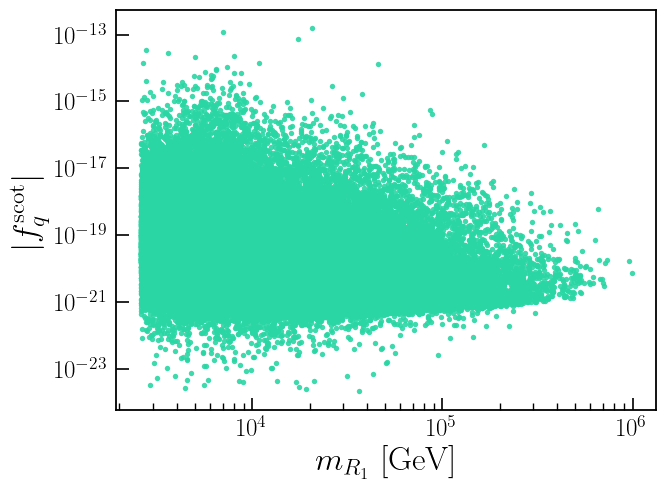

In [14]:
plt.style.use('./paper_style_colorbar.mplstyle')

fig = plt.figure(figsize=(9, 5))
ax_main = fig.add_axes([0.1, 0.1, 0.6, 0.8])
trans_xaxes_ydata = transforms.blended_transform_factory(ax_main.transAxes, ax_main.transData)

x = np.linspace(-100, 100, 10000)
y = np.abs(1 + x)**2

sm = 2.2198e-10

A = ftree/XDD

B = fEW/sm

sc_main = sp_scatter(ax_main, mR1, np.abs(fscoto), allow_cond=None, c_theme=c6, x_lab=r'$m_{R_1}$ [GeV]',
                    y_lab=r'$|f^{\rm scot}_q|$', lw=0.0)

#ax_main.plot(x, y, color='red', linewidth=1.1, label=r'$y = |1 + x^2|$')
'''
ax_main.vlines(x=-1, ymin=1e-6, ymax=1e5, color=c1, linestyle='--', linewidth=1.5, zorder=4)
ax_main.hlines(1, xmin=-10, xmax=10, color='k', linestyle='--', linewidth=1.2, zorder=2)

ax_main.text(
    0.36, 1e1, r"$r_N=-1$",
    transform=trans_xaxes_ydata,
    va='center', ha='left',
    fontsize=16, color=c1,
    rotation=90,
    zorder=10
)

ax_main.text(
    0.6, 1.5, r"Constructive interference",
    transform=trans_xaxes_ydata,
    va='center', ha='left',
    fontsize=12, color='k',
    rotation=0,
    zorder=10
)

ax_main.text(
    0.61, 0.5, r"Destructive interference",
    transform=trans_xaxes_ydata,
    va='center', ha='left',
    fontsize=12, color='k',
    rotation=0,
    zorder=10
)
'''
ax_main.set_yscale("log")
ax_main.set_xscale("log")

#ax_main.set_ylim(1e-5, 1e2)
#ax_main.set_xlim(-5, 5)

#plt.savefig("DD_01.pdf", format="pdf", dpi=300, bbox_inches="tight")
#plt.savefig("p2.png", format="png", dpi=300, bbox_inches="tight")

plt.show()

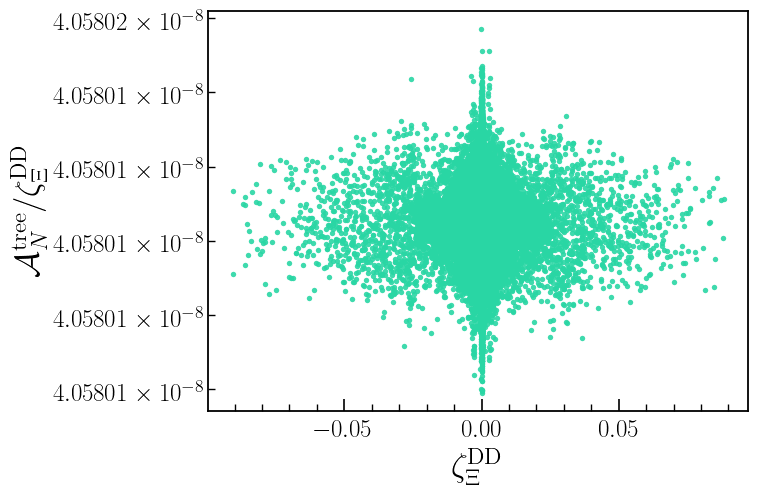

In [15]:
plt.style.use('./paper_style_colorbar.mplstyle')

fig = plt.figure(figsize=(9, 5))
ax_main = fig.add_axes([0.1, 0.1, 0.6, 0.8])
trans_xaxes_ydata = transforms.blended_transform_factory(ax_main.transAxes, ax_main.transData)

x = np.linspace(-100, 100, 10000)
y = np.abs(1 + x)**2

sm = 2.2198e-10

A = ftree/XDD

B = fEW/sm

sc_main = sp_scatter(ax_main, XDD, A, allow_cond=None, c_theme=c6, x_lab=r'$\zeta_\Xi^{\rm DD}$',
                    y_lab=r'$\mathcal{A}_{N}^{\rm tree}/\zeta_\Xi^{\rm DD}$', lw=0.0)

#ax_main.plot(x, y, color='red', linewidth=1.1, label=r'$y = |1 + x^2|$')
'''
ax_main.vlines(x=-1, ymin=1e-6, ymax=1e5, color=c1, linestyle='--', linewidth=1.5, zorder=4)
ax_main.hlines(1, xmin=-10, xmax=10, color='k', linestyle='--', linewidth=1.2, zorder=2)

ax_main.text(
    0.36, 1e1, r"$r_N=-1$",
    transform=trans_xaxes_ydata,
    va='center', ha='left',
    fontsize=16, color=c1,
    rotation=90,
    zorder=10
)

ax_main.text(
    0.6, 1.5, r"Constructive interference",
    transform=trans_xaxes_ydata,
    va='center', ha='left',
    fontsize=12, color='k',
    rotation=0,
    zorder=10
)

ax_main.text(
    0.61, 0.5, r"Destructive interference",
    transform=trans_xaxes_ydata,
    va='center', ha='left',
    fontsize=12, color='k',
    rotation=0,
    zorder=10
)
'''
ax_main.set_yscale("log")
#ax_main.set_xscale("log")

#ax_main.set_ylim(1e-5, 1e2)
#ax_main.set_xlim(-5, 5)

#plt.savefig("DD_01.pdf", format="pdf", dpi=300, bbox_inches="tight")
#plt.savefig("p2.png", format="png", dpi=300, bbox_inches="tight")

plt.show()

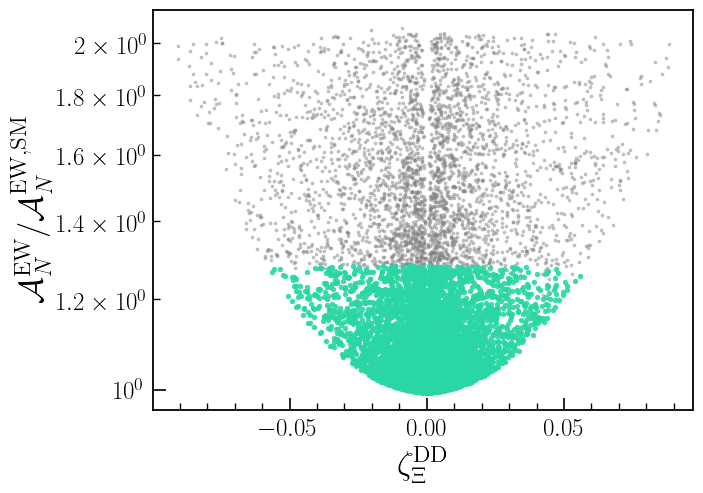

In [16]:
plt.style.use('./paper_style_colorbar.mplstyle')

fig = plt.figure(figsize=(9, 5))
ax_main = fig.add_axes([0.1, 0.1, 0.6, 0.8])
trans_xaxes_ydata = transforms.blended_transform_factory(ax_main.transAxes, ax_main.transData)

x = np.linspace(-100, 100, 10000)
y = np.abs(1 + x)**2

sm = 2.2198e-10

A = ftree/XDD

B = fEW/sm

C = np.sin(2*alpha)*(1-(mh**2/mHH**2))

sc_main = sp_scatter(ax_main, XDD, B, allow_cond=np.cos(alpha) > 0.95, c_theme=c6, x_lab=r'$\zeta_\Xi^{\rm DD}$',
                    y_lab=r'$\mathcal{A}_{N}^{\rm EW}/\mathcal{A}_{N}^{\rm EW, SM}$', lw=0.0)

sc_main = sp_scatter(ax_main, XDD, B, allow_cond=np.cos(alpha) > 0.95, c_theme=c6, x_lab=r'$\zeta_\Xi^{\rm DD}$',
                    y_lab=r'$\mathcal{A}_{N}^{\rm EW}/\mathcal{A}_{N}^{\rm EW, SM}$', lw=0.0)

#ax_main.plot(x, y, color='red', linewidth=1.1, label=r'$y = |1 + x^2|$')
'''
ax_main.vlines(x=-1, ymin=1e-6, ymax=1e5, color=c1, linestyle='--', linewidth=1.5, zorder=4)
ax_main.hlines(1, xmin=-10, xmax=10, color='k', linestyle='--', linewidth=1.2, zorder=2)

ax_main.text(
    0.36, 1e1, r"$r_N=-1$",
    transform=trans_xaxes_ydata,
    va='center', ha='left',
    fontsize=16, color=c1,
    rotation=90,
    zorder=10
)

ax_main.text(
    0.6, 1.5, r"Constructive interference",
    transform=trans_xaxes_ydata,
    va='center', ha='left',
    fontsize=12, color='k',
    rotation=0,
    zorder=10
)

ax_main.text(
    0.61, 0.5, r"Destructive interference",
    transform=trans_xaxes_ydata,
    va='center', ha='left',
    fontsize=12, color='k',
    rotation=0,
    zorder=10
)
'''
ax_main.set_yscale("log")
#ax_main.set_xscale("log")

#ax_main.set_ylim(1e-5, 1e2)
#ax_main.set_xlim(-5, 5)

#plt.savefig("DD_01.pdf", format="pdf", dpi=300, bbox_inches="tight")
#plt.savefig("p2.png", format="png", dpi=300, bbox_inches="tight")

plt.show()

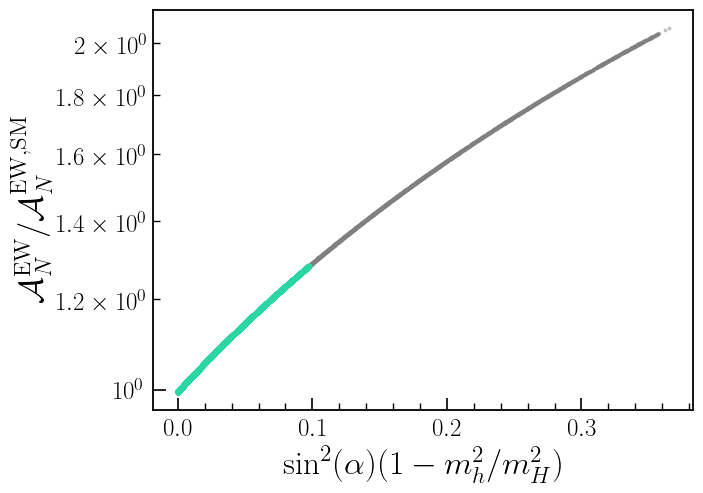

In [38]:
plt.style.use('./paper_style_colorbar.mplstyle')

fig = plt.figure(figsize=(9, 5))
ax_main = fig.add_axes([0.1, 0.1, 0.6, 0.8])
trans_xaxes_ydata = transforms.blended_transform_factory(ax_main.transAxes, ax_main.transData)

x = np.linspace(-100, 100, 10000)
y = np.abs(1 + x)**2

sm = 2.2198e-10

A = ftree/XDD

B = fEW/sm

C = np.sin(alpha)**2*(1-(mh**2/mHH**2))

sc_main = sp_scatter(ax_main, C, B, allow_cond= np.cos(alpha) > 0.95, c_theme=c6, x_lab=r'$\sin^2(\alpha)(1-m_h^2/m_H^2)$',
                    y_lab=r'$\mathcal{A}_{N}^{\rm EW}/\mathcal{A}_{N}^{\rm EW, SM}$', lw=0.0)

#ax_main.plot(x, y, color='red', linewidth=1.1, label=r'$y = |1 + x^2|$')
'''
ax_main.vlines(x=-1, ymin=1e-6, ymax=1e5, color=c1, linestyle='--', linewidth=1.5, zorder=4)
ax_main.hlines(1, xmin=-10, xmax=10, color='k', linestyle='--', linewidth=1.2, zorder=2)

ax_main.text(
    0.36, 1e1, r"$r_N=-1$",
    transform=trans_xaxes_ydata,
    va='center', ha='left',
    fontsize=16, color=c1,
    rotation=90,
    zorder=10
)

ax_main.text(
    0.6, 1.5, r"Constructive interference",
    transform=trans_xaxes_ydata,
    va='center', ha='left',
    fontsize=12, color='k',
    rotation=0,
    zorder=10
)

ax_main.text(
    0.61, 0.5, r"Destructive interference",
    transform=trans_xaxes_ydata,
    va='center', ha='left',
    fontsize=12, color='k',
    rotation=0,
    zorder=10
)
'''
ax_main.set_yscale("log")
#ax_main.set_xscale("log")

#ax_main.set_ylim(1e-5, 1e2)
#ax_main.set_xlim(-5, 5)

#plt.savefig("DD_01.pdf", format="pdf", dpi=300, bbox_inches="tight")
#plt.savefig("p2.png", format="png", dpi=300, bbox_inches="tight")

plt.show()

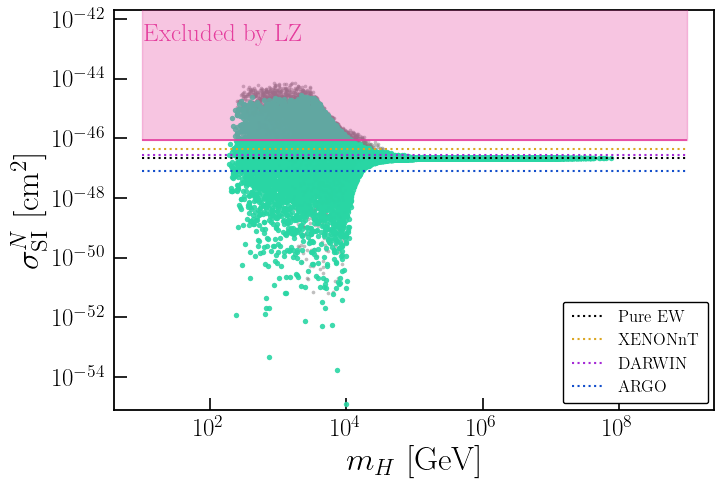

In [18]:
plt.style.use('./paper_style_colorbar.mplstyle')

fig = plt.figure(figsize=(10, 5))
ax_main = fig.add_axes([0.1, 0.1, 0.6, 0.8])
trans_xaxes_ydata = transforms.blended_transform_factory(ax_main.transAxes, ax_main.transData)
'''
niveles_rN = [1]

contornos = ax_main.tricontour(mHH, sigma_SI, rN, 
                               levels=niveles_rN, 
                               colors='black', 
                               linewidths=1.5,
                               linestyles=['--'], zorder=3)
'''
sc_main= sp_scatter(ax_main, mHH, sigma_SI, allow_cond= np.cos(alpha) > 0.95, c_theme=c6, x_lab=r'$m_H$ [GeV]',
                    y_lab=r'$\sigma^{N}_{\rm SI}$ [cm$^2$]', lw=0.0)

#ax_main.vlines(x=125, ymin=1e-55, ymax=1e-9, color=c2, linestyle='--', linewidth=1.2, zorder=3)

ax_main.hlines(LZ, xmin=1e1, xmax=1e9, color=c1, linestyle='-', linewidth=1.2, zorder=2)
ax_main.hlines(2.15e-47, xmin=1e1, xmax=1e9, color='k', linestyle=':', linewidth=1.5, zorder=2, label=r'Pure EW')
ax_main.hlines(XENONnT, xmin=1e1, xmax=1e9, color=c5, linestyle=':', linewidth=1.5, zorder=2, label=r'XENONnT')
ax_main.hlines(DARWIN, xmin=1e1, xmax=1e9, color=c4, linestyle=':', linewidth=1.5, zorder=2, label=r'DARWIN')
ax_main.hlines(ARGO, xmin=1e1, xmax=1e9, color=c0, linestyle=':', linewidth=1.5, zorder=2, label=r'ARGO')

ax_main.fill_between(
        x=np.linspace(1e1, 1e9, 10),
        y1=LZ,
        y2=1e-40,
        color=c1, 
        alpha=0.3,    
        zorder=3, rasterized=True    
        )

ax_main.text(
    0.05, 3e-43, r"Excluded by LZ",
    transform=trans_xaxes_ydata,
    va='center', ha='left',
    fontsize=18, color=c1,
    rotation=0,
    zorder=10
)

ax_main.set_yscale("log")
ax_main.set_xscale("log")

ax_main.set_ylim(8e-56, 2e-42)
#ax_main.set_xlim(0.9e2, 2e5)

leg=ax_main.legend(
    #title="Title",
    #title_fontsize=10,
    fontsize=12,
    loc="lower right", 
    frameon=True
)
leg.get_frame().set_linewidth(1) 
leg.get_frame().set_alpha(1)
leg.get_frame().set_edgecolor("black")
leg.get_frame().set_boxstyle("Round,pad=0.1")

#plt.savefig("DD_04.pdf", format="pdf", dpi=300, bbox_inches="tight")
#plt.savefig("p1.png", format="png", dpi=300, bbox_inches="tight")

plt.show()

ValueError: (0.1607843137254902, 0.8392156862745098, 0.6431372549019608) is not a valid value for name; supported values are 'Accent', 'Accent_r', 'Blues', 'Blues_r', 'BrBG', 'BrBG_r', 'BuGn', 'BuGn_r', 'BuPu', 'BuPu_r', 'CMRmap', 'CMRmap_r', 'Dark2', 'Dark2_r', 'GnBu', 'GnBu_r', 'Grays', 'Grays_r', 'Greens', 'Greens_r', 'Greys', 'Greys_r', 'OrRd', 'OrRd_r', 'Oranges', 'Oranges_r', 'PRGn', 'PRGn_r', 'Paired', 'Paired_r', 'Pastel1', 'Pastel1_r', 'Pastel2', 'Pastel2_r', 'PiYG', 'PiYG_r', 'PuBu', 'PuBuGn', 'PuBuGn_r', 'PuBu_r', 'PuOr', 'PuOr_r', 'PuRd', 'PuRd_r', 'Purples', 'Purples_r', 'RdBu', 'RdBu_r', 'RdGy', 'RdGy_r', 'RdPu', 'RdPu_r', 'RdYlBu', 'RdYlBu_r', 'RdYlGn', 'RdYlGn_r', 'Reds', 'Reds_r', 'Set1', 'Set1_r', 'Set2', 'Set2_r', 'Set3', 'Set3_r', 'Spectral', 'Spectral_r', 'Wistia', 'Wistia_r', 'YlGn', 'YlGnBu', 'YlGnBu_r', 'YlGn_r', 'YlOrBr', 'YlOrBr_r', 'YlOrRd', 'YlOrRd_r', 'afmhot', 'afmhot_r', 'autumn', 'autumn_r', 'berlin', 'berlin_r', 'binary', 'binary_r', 'bone', 'bone_r', '

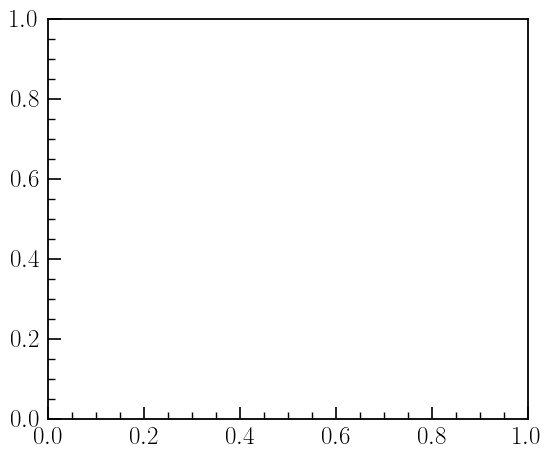

In [27]:
plt.style.use('./paper_style_colorbar.mplstyle')

fig = plt.figure(figsize=(8, 5))
ax_main = fig.add_axes([0.1, 0.1, 0.6, 0.8])
trans_xaxes_ydata = transforms.blended_transform_factory(ax_main.transAxes, ax_main.transData)

pmask = XDD < 0

A = -XDD[pmask]
B = sigma_SI[pmask]
#C = sigma_SI[pmask]/sEW[pmask]
#D = rN[pmask]
E = rN[pmask]

sc_main= cb_scatter(ax_main, A, B, E, allow_cond= np.cos(alpha[pmask]) > 0.95, c_theme=c6, x_lab=r'$\zeta_\Xi^{\rm DD}<0$',
                    y_lab=r'$\sigma^{N}_{\rm SI}$ [cm$^2$]', lw=0.0)

ax_main.hlines(LZ, xmin=1e-15, xmax=1e0, color=c1, linestyle='-', linewidth=1.5, zorder=2)
ax_main.hlines(2.15e-47, xmin=1e-15, xmax=1e0, color='k', linestyle=':', linewidth=1.5, zorder=2, label=r'Pure EW')
ax_main.hlines(XENONnT, xmin=1e-15, xmax=1e0, color=c5, linestyle=':', linewidth=1.5, zorder=2, label=r'XENONnT')
ax_main.hlines(DARWIN, xmin=1e-15, xmax=1e0, color=c4, linestyle=':', linewidth=1.5, zorder=2, label=r'DARWIN')
ax_main.hlines(ARGO, xmin=1e-15, xmax=1e0, color=c0, linestyle=':', linewidth=1.5, zorder=2, label=r'ARGO')

ax_main.fill_between(
        x=np.linspace(1e-15, 1e0, 10),
        y1=LZ,
        y2=1e-40,
        color=c1, 
        alpha=0.3,    
        zorder=3, rasterized=True    
        )

ax_main.text(
    0.05, 9e-46, r"Excluded by LZ",
    transform=trans_xaxes_ydata,
    va='center', ha='left',
    fontsize=18, color=c1,
    rotation=0,
    zorder=10
)

ax_main.set_yscale("log")
ax_main.set_xscale("log")

ax_main.set_ylim(8e-50, 2e-45)
ax_main.set_xlim(0.9e-8, 2e-1)

leg=ax_main.legend(
    #title="Title",
    #title_fontsize=10,
    fontsize=12, 
    loc="lower left", 
    frameon=True
)
leg.get_frame().set_linewidth(1) 
leg.get_frame().set_alpha(1)
leg.get_frame().set_edgecolor("black")
leg.get_frame().set_boxstyle("Round,pad=0.1")

#plt.savefig("DD_03-1.pdf", format="pdf", dpi=300, bbox_inches="tight")
#plt.savefig("p1.png", format="png", dpi=300, bbox_inches="tight")

plt.show()

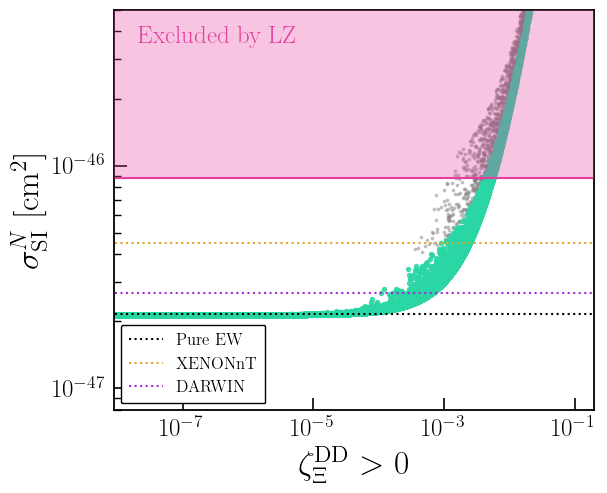

In [20]:
plt.style.use('./paper_style_colorbar.mplstyle')

fig = plt.figure(figsize=(8, 5))
ax_main = fig.add_axes([0.1, 0.1, 0.6, 0.8])
trans_xaxes_ydata = transforms.blended_transform_factory(ax_main.transAxes, ax_main.transData)

pmask = XDD > 0

A = XDD[pmask]
B = sigma_SI[pmask]
#C = sigma_SI[pmask]/sEW[pmask]
#D = rN[pmask]
E = rN[pmask]

sc_main= sp_scatter(ax_main, A, B, allow_cond=np.cos(alpha[pmask]) > 0.95, c_theme=c6, x_lab=r'$\zeta_\Xi^{\rm DD}>0$',
                    y_lab=r'$\sigma^{N}_{\rm SI}$ [cm$^2$]', lw=0.0)

ax_main.hlines(LZ, xmin=1e-15, xmax=1e0, color=c1, linestyle='-', linewidth=1.5, zorder=2)
ax_main.hlines(2.15e-47, xmin=1e-15, xmax=1e0, color='k', linestyle=':', linewidth=1.5, zorder=2, label=r'Pure EW')
ax_main.hlines(XENONnT, xmin=1e-15, xmax=1e0, color=c5, linestyle=':', linewidth=1.5, zorder=2, label=r'XENONnT')
ax_main.hlines(DARWIN, xmin=1e-15, xmax=1e0, color=c4, linestyle=':', linewidth=1.5, zorder=2, label=r'DARWIN')
#ax_main.hlines(ARGO, xmin=1e-15, xmax=1e0, color=c0, linestyle=':', linewidth=1.5, zorder=2, label=r'ARGO')

ax_main.fill_between(
        x=np.linspace(1e-15, 1e0, 10),
        y1=LZ,
        y2=1e-40,
        color=c1, 
        alpha=0.3,    
        zorder=3, rasterized=True    
        )

ax_main.text(
    0.05, 3.8e-46, r"Excluded by LZ",
    transform=trans_xaxes_ydata,
    va='center', ha='left',
    fontsize=18, color=c1,
    rotation=0,
    zorder=10
)

ax_main.set_yscale("log")
ax_main.set_xscale("log")

ax_main.set_ylim(8e-48, 5e-46)
ax_main.set_xlim(0.9e-8, 2e-1)

leg=ax_main.legend(
    #title="Title",
    #title_fontsize=10,
    fontsize=12, 
    loc="lower left", 
    frameon=True
)
leg.get_frame().set_linewidth(1) 
leg.get_frame().set_alpha(1)
leg.get_frame().set_edgecolor("black")
leg.get_frame().set_boxstyle("Round,pad=0.1")

plt.savefig("DD_03-2.pdf", format="pdf", dpi=300, bbox_inches="tight")
#plt.savefig("p1.png", format="png", dpi=300, bbox_inches="tight")

plt.show()

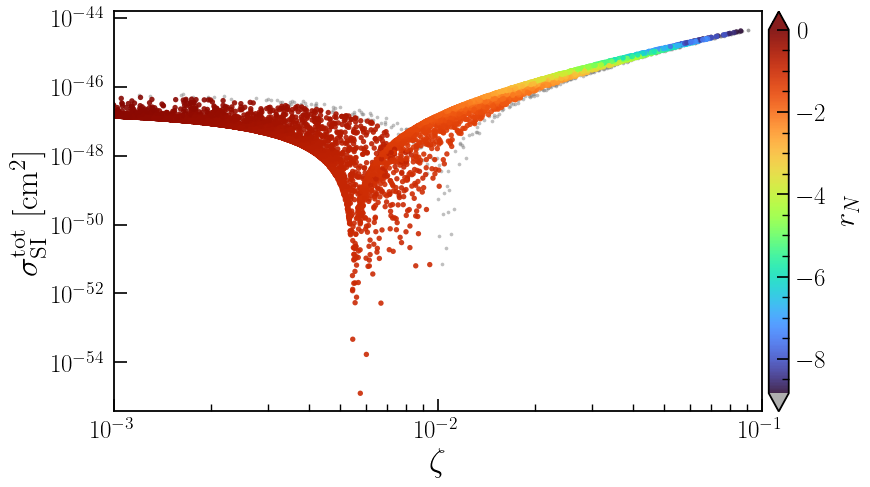

In [35]:
plt.style.use('./paper_style_colorbar.mplstyle')

fig = plt.figure(figsize=(12, 5))
ax_main = fig.add_axes([0.1, 0.1, 0.6, 0.8])
trans_xaxes_ydata = transforms.blended_transform_factory(ax_main.transAxes, ax_main.transData)

pmask = XDD < 0

A = -XDD[pmask]
B = sigma_SI[pmask]
#C = sigma_SI[pmask]/sEW[pmask]
#D = rN[pmask]
E = rN[pmask]


sc_main= cb_scatter(ax_main, A, B, E, allow_cond= (kappa_F[pmask]>ckw), cb_pos='lat', x_lab=r'$\zeta$',
                    y_lab=r'$\sigma^{\rm tot}_{\rm SI}$ [cm$^2$]', c_lab=r'$r_N$', 
                    c_theme='turbo', lw=0.0)

ax_main.set_yscale("log")
ax_main.set_xscale("log")

#ax_main.set_ylim(8e-52, 2e-42)
ax_main.set_xlim(1e-3, 1e-1)

#plt.savefig("p1.pdf", format="pdf", dpi=300, bbox_inches="tight")
#plt.savefig("p1.png", format="png", dpi=300, bbox_inches="tight")

plt.show()

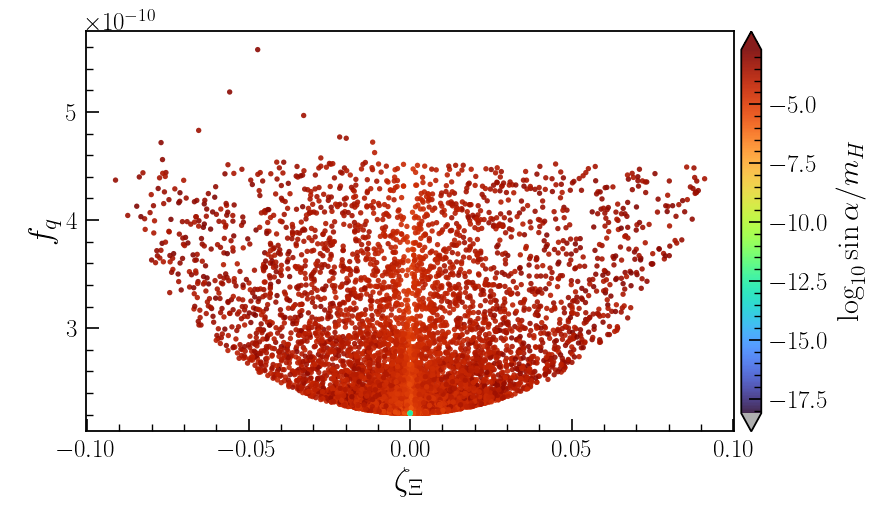

In [15]:
plt.style.use('./paper_style_colorbar.mplstyle')

fig = plt.figure(figsize=(12, 5))
ax_main = fig.add_axes([0.1, 0.1, 0.6, 0.8])
trans_xaxes_ydata = transforms.blended_transform_factory(ax_main.transAxes, ax_main.transData)

sc_main= cb_scatter(ax_main, XDD, fEW, np.log10(np.abs(np.sin(alpha)/mHH)), allow_cond= (vsigma > 100), cb_pos='lat', x_lab=r'$\zeta_\Xi$',
                    y_lab=r'$f_q$', c_lab=r'$\log_{10}\sin\alpha/m_H$', 
                    c_theme='turbo', lw=0.0)

#ax_main.set_yscale("log")
#ax_main.set_xscale("log")

#ax_main.set_ylim(8e-52, 2e-42)
#ax_main.set_xlim(1e-6, 1e1)

#plt.savefig("p1.pdf", format="pdf", dpi=300, bbox_inches="tight")
#plt.savefig("p1.png", format="png", dpi=300, bbox_inches="tight")

plt.show()

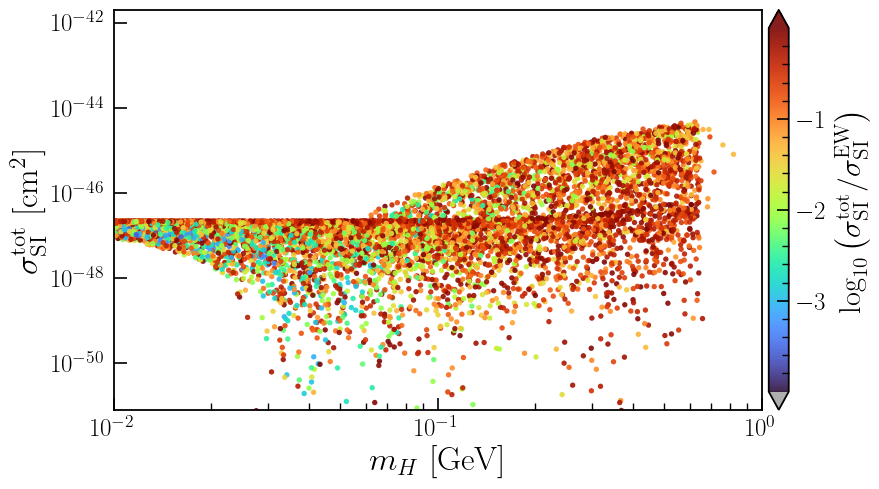

In [16]:
plt.style.use('./paper_style_colorbar.mplstyle')

fig = plt.figure(figsize=(12, 5))
ax_main = fig.add_axes([0.1, 0.1, 0.6, 0.8])
trans_xaxes_ydata = transforms.blended_transform_factory(ax_main.transAxes, ax_main.transData)

sc_main= cb_scatter(ax_main, -alpha, sigma_SI, np.log10(np.abs(lamb_phi_sigma)), allow_cond= (vsigma > 100), cb_pos='lat', x_lab=r'$m_H$ [GeV]',
                    y_lab=r'$\sigma^{\rm tot}_{\rm SI}$ [cm$^2$]', c_lab=r'$\log_{10}\left(\sigma^{\rm tot}_{\rm SI}/\sigma^{\rm EW}_{\rm SI}\right)$', 
                    c_theme='turbo', lw=0.0)

ax_main.set_yscale("log")
ax_main.set_xscale("log")

ax_main.set_ylim(8e-52, 2e-42)
ax_main.set_xlim(1e-2, 1e0)

#plt.savefig("p1.pdf", format="pdf", dpi=300, bbox_inches="tight")
#plt.savefig("p1.png", format="png", dpi=300, bbox_inches="tight")

plt.show()

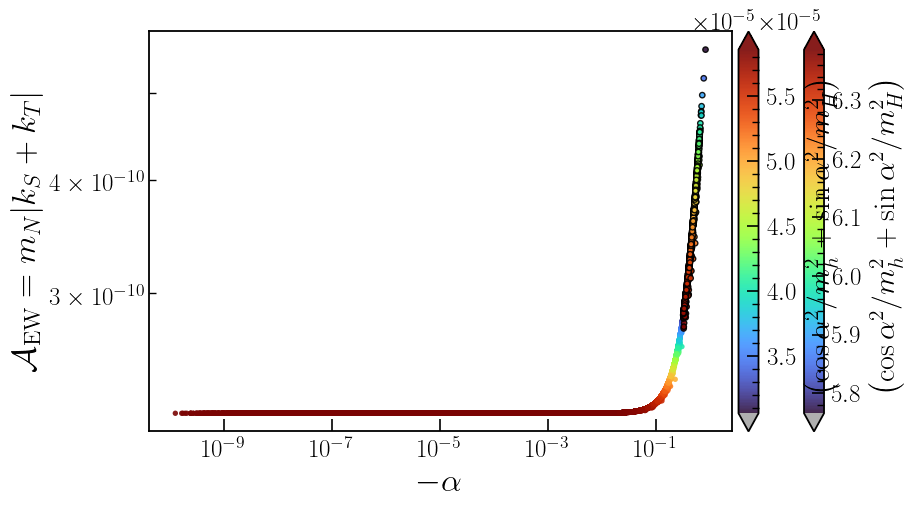

In [17]:
plt.style.use('./paper_style_colorbar.mplstyle')

fig = plt.figure(figsize=(12, 5))
ax_main = fig.add_axes([0.1, 0.1, 0.6, 0.8])
trans_xaxes_ydata = transforms.blended_transform_factory(ax_main.transAxes, ax_main.transData)

con = ((np.cos(alpha)**2)/mh**2+(np.sin(alpha)**2)/mHH**2)

pmask = np.cos(alpha) > 0.95

p2mask = np.cos(alpha) < 0.95

A = -alpha[pmask]
B = fEW[pmask]
C = con[pmask]

A2 = -alpha[p2mask]
B2 = fEW[p2mask]
C2 = con[p2mask]

sc_main= cb_scatter(ax_main, A, B, C, allow_cond=None, cb_pos='lat', x_lab=r'$-\alpha$',
                    y_lab=r'$\mathcal{A}_{\rm EW}=m_N|k_S+k_T|$', c_lab=r'$\left(\cos\alpha^2/m_h^2+\sin\alpha^2/m_H^2\right)$', 
                    c_theme='turbo', lw=0.0)

sc_main2= cb_scatter(ax_main, A2, B2, C2, allow_cond=None, cb_pos='lat', x_lab=r'$-\alpha$',
                    y_lab=r'$\mathcal{A}_{\rm EW}=m_N|k_S+k_T|$', c_lab=r'$\left(\cos\alpha^2/m_h^2+\sin\alpha^2/m_H^2\right)$', 
                    c_theme='turbo', lw=1.0)
#ax_main.vlines(x=125, ymin=1e-11, ymax=1e-9, color=c2, linestyle='--', linewidth=1.2, zorder=3)

ax_main.set_yscale("log")
ax_main.set_xscale("log")

#ax_main.set_ylim(8e-52, 2e-42)
#ax_main.set_xlim(1e-1, 1e0)

#plt.savefig("p1.pdf", format="pdf", dpi=300, bbox_inches="tight")
#plt.savefig("p1.png", format="png", dpi=300, bbox_inches="tight")

plt.show()

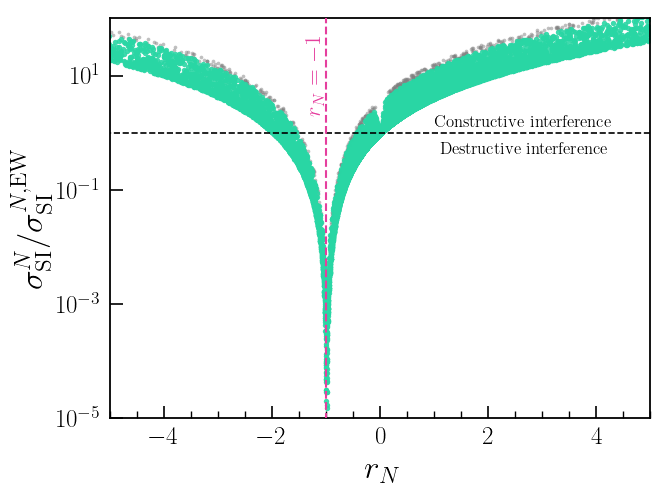

In [36]:
plt.style.use('./paper_style_colorbar.mplstyle')

fig = plt.figure(figsize=(9, 5))
ax_main = fig.add_axes([0.1, 0.1, 0.6, 0.8])
trans_xaxes_ydata = transforms.blended_transform_factory(ax_main.transAxes, ax_main.transData)

x = np.linspace(-100, 100, 10000)
y = np.abs(1 + x)**2

sc_main = sp_scatter(ax_main, rN, sigma_SI/2.15e-47, allow_cond= (kappa_F>ckw), c_theme=c6, x_lab=r'$r_N$',
                    y_lab=r'$\sigma^{N}_{\rm SI}/\sigma^{N,\rm{EW}}_{\rm SI}$', lw=0.0)

#ax_main.plot(x, y, color='red', linewidth=1.1, label=r'$y = |1 + x^2|$')

ax_main.vlines(x=-1, ymin=1e-6, ymax=1e5, color=c1, linestyle='--', linewidth=1.5, zorder=4)
ax_main.hlines(1, xmin=-10, xmax=10, color='k', linestyle='--', linewidth=1.2, zorder=2)

ax_main.text(
    0.36, 1e1, r"$r_N=-1$",
    transform=trans_xaxes_ydata,
    va='center', ha='left',
    fontsize=16, color=c1,
    rotation=90,
    zorder=10
)

ax_main.text(
    0.6, 1.5, r"Constructive interference",
    transform=trans_xaxes_ydata,
    va='center', ha='left',
    fontsize=12, color='k',
    rotation=0,
    zorder=10
)

ax_main.text(
    0.61, 0.5, r"Destructive interference",
    transform=trans_xaxes_ydata,
    va='center', ha='left',
    fontsize=12, color='k',
    rotation=0,
    zorder=10
)

ax_main.set_yscale("log")
#ax_main.set_xscale("log")

ax_main.set_ylim(1e-5, 1e2)
ax_main.set_xlim(-5, 5)

#plt.savefig("DD_01.pdf", format="pdf", dpi=300, bbox_inches="tight")
#plt.savefig("p2.png", format="png", dpi=300, bbox_inches="tight")

plt.show()

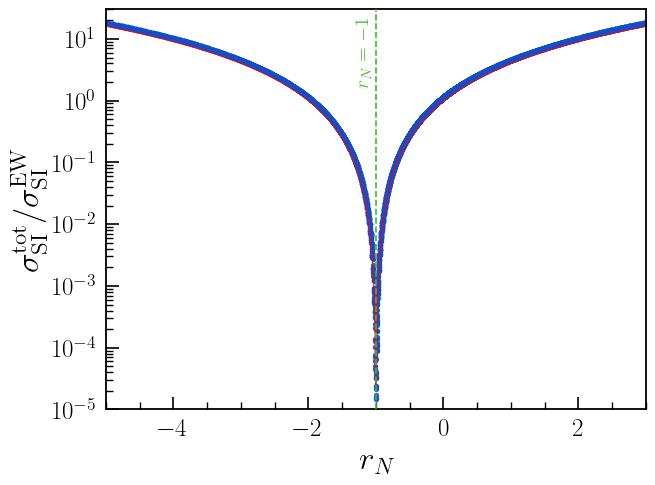

In [19]:
plt.style.use('./paper_style_colorbar.mplstyle')

fig = plt.figure(figsize=(9, 5))
ax_main = fig.add_axes([0.1, 0.1, 0.6, 0.8])
trans_xaxes_ydata = transforms.blended_transform_factory(ax_main.transAxes, ax_main.transData)

x = np.linspace(-100, 100, 20000)
y = np.abs(1 + x)**2

sc_main = sp_scatter(ax_main, rN, sigma_SI/sEW, allow_cond= (kappa_F>ckw), x_lab=r'$r_N$',
                    y_lab=r'$\sigma^{\rm tot}_{\rm SI}/\sigma^{\rm EW}_{\rm SI}$', lw=0.0)

ax_main.plot(x, y, color='red', linewidth=0.7, label=r'$y = |1 + x^2|$')

ax_main.vlines(x=-1, ymin=1e-6, ymax=1e5, color=c2, linestyle='--', linewidth=1.2, zorder=3)

ax_main.text(
    0.46, 0.6e1, r"$r_N=-1$",
    transform=trans_xaxes_ydata,
    va='center', ha='left',
    fontsize=14, color=c2,
    rotation=90,
    zorder=10
)

ax_main.set_yscale("log")
#ax_main.set_xscale("log")

ax_main.set_ylim(1e-5, 3e1)
ax_main.set_xlim(-5, 3)

#plt.savefig("p2.pdf", format="pdf", dpi=300, bbox_inches="tight")
#plt.savefig("p2.png", format="png", dpi=300, bbox_inches="tight")

plt.show()

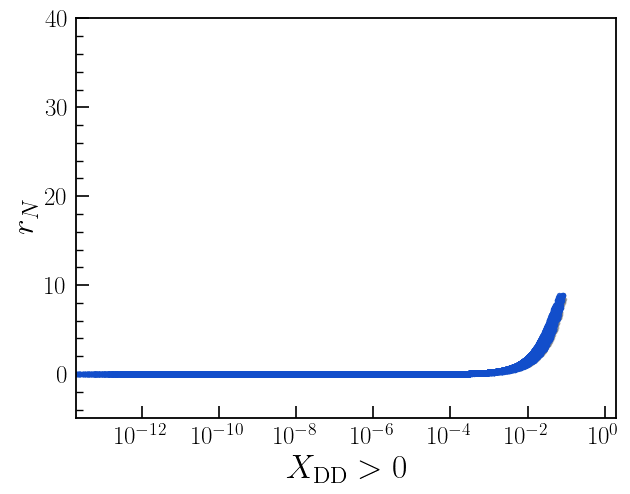

In [20]:
plt.style.use('./paper_style_colorbar.mplstyle')

fig = plt.figure(figsize=(9, 5))
ax_main = fig.add_axes([0.1, 0.1, 0.6, 0.8])
trans_xaxes_ydata = transforms.blended_transform_factory(ax_main.transAxes, ax_main.transData)

pmask = XDD >= 0

A = XDD[pmask]
B = rN[pmask]
#C = sigma_SI[pmask]/sEW[pmask]
#D = rN[pmask]
E = kappa_F[pmask]

sc_main = sp_scatter(ax_main, A, B, allow_cond= (E > ckw), x_lab=r'$X_{\rm DD}>0$',
                    y_lab=r'$r_N$', lw=0.0)

#ax_main.hlines(-1, xmin=1e-13, xmax=1e-1, color=c2, linestyle='--', linewidth=1.2, zorder=2)

#ax_main.set_yscale("log")
ax_main.set_xscale("log")

ax_main.set_ylim(-5, 40)
ax_main.set_xlim(2e-14, 2e0)

#plt.savefig("p3-1.pdf", format="pdf", dpi=300, bbox_inches="tight")
#plt.savefig("p3-1.png", format="png", dpi=300, bbox_inches="tight")

plt.show()

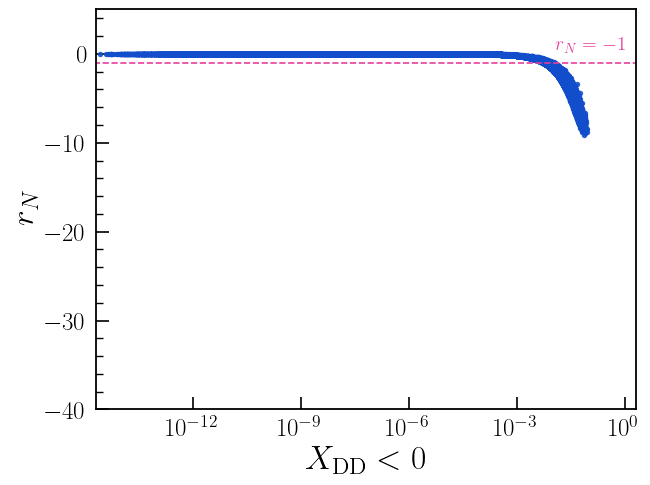

In [21]:
plt.style.use('./paper_style_colorbar.mplstyle')

fig = plt.figure(figsize=(9, 5))
ax_main = fig.add_axes([0.1, 0.1, 0.6, 0.8])
trans_xaxes_ydata = transforms.blended_transform_factory(ax_main.transAxes, ax_main.transData)

pmask = XDD < 0

A = -XDD[pmask]
B = rN[pmask]
#C = sigma_SI[pmask]/sEW[pmask]
#D = rN[pmask]
E = vsigma[pmask]

sc_main = sp_scatter(ax_main, A, B, allow_cond= (E > 3000), x_lab=r'$X_{\rm DD}<0$',
                    y_lab=r'$r_N$', lw=0.0)

ax_main.hlines(-1, xmin=1e-15, xmax=1e1, color=c1, linestyle='--', linewidth=1.2, zorder=2)

ax_main.text(
    0.85, 1, r"$r_N=-1$",
    transform=trans_xaxes_ydata,
    va='center', ha='left',
    fontsize=14, color=c1,
    rotation=0,
    zorder=10
)

#ax_main.set_yscale("log")
ax_main.set_xscale("log")

ax_main.set_ylim(-40, 5)
ax_main.set_xlim(2e-15, 2e0)

#plt.savefig("p3-2.pdf", format="pdf", dpi=300, bbox_inches="tight")
#plt.savefig("p3-2.png", format="png", dpi=300, bbox_inches="tight")

plt.show()

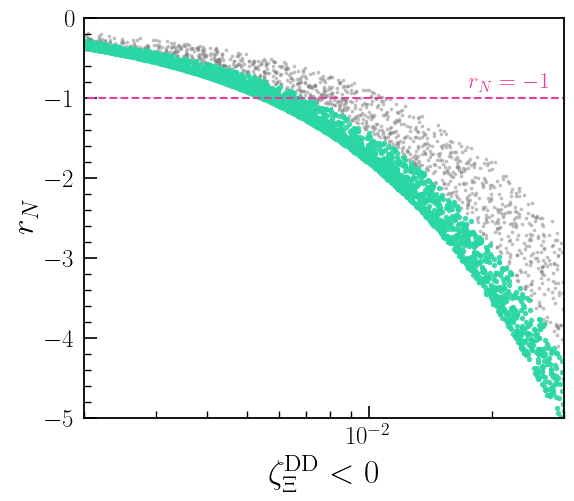

In [23]:
plt.style.use('./paper_style_colorbar.mplstyle')

fig = plt.figure(figsize=(8, 5))
ax_main = fig.add_axes([0.1, 0.1, 0.6, 0.8])
trans_xaxes_ydata = transforms.blended_transform_factory(ax_main.transAxes, ax_main.transData)

pmask = XDD < 0

A = -XDD[pmask]
B = rN[pmask]
C = mHH[pmask]
#D = rN[pmask]
E = vsigma[pmask]

F = np.cos(alpha[pmask])

#sc_main = sp_scatter(ax_main, A, B, allow_cond= (E > 3000), x_lab=r'$X_{\rm DD}<0$',
#                    y_lab=r'$r_N$', lw=0.0)

sc_main= sp_scatter(ax_main, A, B, allow_cond=(F>0.95), c_theme=c6, x_lab=r'$\zeta_\Xi^{\rm DD}<0$',
                    y_lab=r'$r_N$',
                   lw=0.0)

ax_main.hlines(-1, xmin=1e-15, xmax=1e1, color=c1, linestyle='--', linewidth=1.5, zorder=2)
#ax_main.vlines(x=5.25e-3, ymin=-10, ymax=10, color=c1, linestyle='--', linewidth=1.2, zorder=2)

ax_main.text(
    0.8, -0.8, r"$r_N=-1$",
    transform=trans_xaxes_ydata,
    va='center', ha='left',
    fontsize=16, color=c1,
    rotation=0,
    zorder=10
)

#ax_main.set_yscale("log")
ax_main.set_xscale("log")

ax_main.set_ylim(-5, 0)
ax_main.set_xlim(2e-3, 3e-2)

#plt.savefig("DD-02.pdf", format="pdf", dpi=300, bbox_inches="tight")
#plt.savefig("p3-2.png", format="png", dpi=300, bbox_inches="tight")

plt.show()

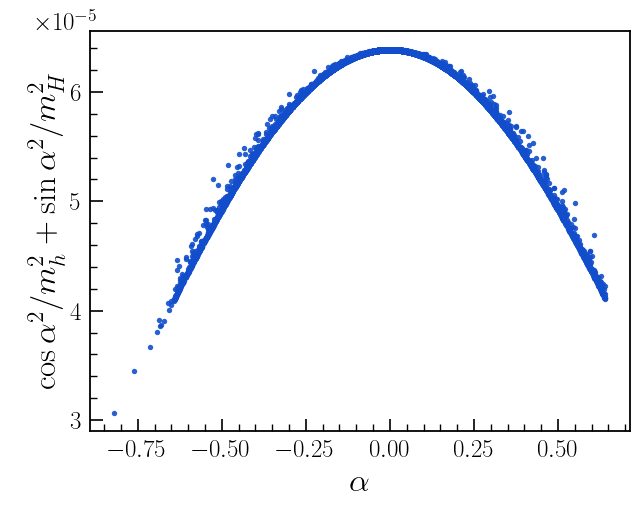

In [23]:
plt.style.use('./paper_style_colorbar.mplstyle')

fig = plt.figure(figsize=(9, 5))
ax_main = fig.add_axes([0.1, 0.1, 0.6, 0.8])
trans_xaxes_ydata = transforms.blended_transform_factory(ax_main.transAxes, ax_main.transData)

con = ((np.cos(alpha)**2)/mh**2+(np.sin(alpha)**2)/mHH**2)

sc_main= sp_scatter(ax_main, alpha, con, allow_cond=None, x_lab=r'$\alpha$',
                    y_lab=r'$\cos\alpha^2/m_h^2+\sin\alpha^2/m_H^2$',
                   lw=0.0)
'''
#ax_main.hlines(kt_s1, xmin=-1.7, xmax=1.7, color=c3, linestyle='-', linewidth=1.2, zorder=2, label=r'DARWIN')
#ax_main.hlines(kt_s3, xmin=-1.7, xmax=1.7, color=c3, linestyle='--', linewidth=1.2, zorder=2, label=r'DARWIN')
#ax_main.hlines(kt_i1, xmin=-1.7, xmax=1.7, color=c3, linestyle='-', linewidth=1.2, zorder=2, label=r'DARWIN')
ax_main.hlines(kt_i3, xmin=-1.7, xmax=1.7, color=c3, linestyle=':', linewidth=1.9, zorder=2, label=r'DARWIN')
ax_main.hlines(ckt, xmin=-1.7, xmax=1.7, color=c3, linestyle='-', linewidth=1, zorder=2, label=r'DARWIN')
#ax_main.hlines(kb_s1, xmin=-1.7, xmax=1.7, color=c2, linestyle='-', linewidth=1.2, zorder=2, label=r'DARWIN')
#ax_main.hlines(kb_s3, xmin=-1.7, xmax=1.7, color=c2, linestyle='--', linewidth=1.2, zorder=2, label=r'DARWIN')
#ax_main.hlines(kb_i1, xmin=-1.7, xmax=1.7, color=c2, linestyle='-', linewidth=1.2, zorder=2, label=r'DARWIN')
ax_main.hlines(kb_i3, xmin=-1.7, xmax=1.7, color=c2, linestyle=':', linewidth=1.9, zorder=2, label=r'DARWIN')
ax_main.hlines(ckb, xmin=-1.7, xmax=1.7, color=c2, linestyle='-', linewidth=1, zorder=2, label=r'DARWIN')
#ax_main.hlines(kw_s1, xmin=-1.7, xmax=1.7, color=c1, linestyle='-', linewidth=1.2, zorder=2, label=r'DARWIN')
#ax_main.hlines(kw_s3, xmin=-1.7, xmax=1.7, color=c1, linestyle='--', linewidth=1.2, zorder=2, label=r'DARWIN')
#ax_main.hlines(kw_i1, xmin=-1.7, xmax=1.7, color=c1, linestyle='-', linewidth=1.2, zorder=2, label=r'DARWIN')
ax_main.hlines(kw_i3, xmin=-1.7, xmax=1.7, color=c1, linestyle=':', linewidth=1.9, zorder=2, label=r'DARWIN')
ax_main.hlines(ckw, xmin=-1.7, xmax=1.7, color=c1, linestyle='-', linewidth=1, zorder=2, label=r'DARWIN')
'''
#ax_main.set_yscale("log")
#ax_main.set_xscale("log")

#ax_main.set_ylim(0.5, 1.1)
#ax_main.set_xlim(-1, 1)

#plt.savefig("p4.pdf", format="pdf", dpi=300, bbox_inches="tight")
#plt.savefig("p4.png", format="png", dpi=300, bbox_inches="tight")

plt.show()

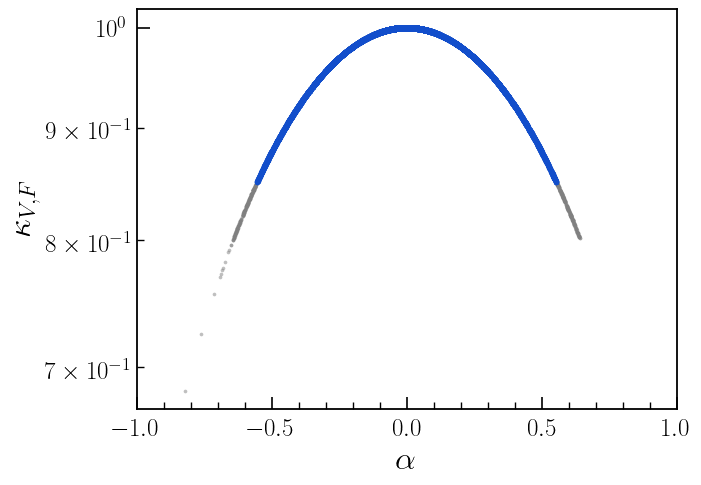

In [24]:
plt.style.use('./paper_style_colorbar.mplstyle')

fig = plt.figure(figsize=(9, 5))
ax_main = fig.add_axes([0.1, 0.1, 0.6, 0.8])
trans_xaxes_ydata = transforms.blended_transform_factory(ax_main.transAxes, ax_main.transData)

sc_main= sp_scatter(ax_main, alpha, np.cos(alpha), allow_cond= (kappa_F>ckw), x_lab=r'$\alpha$',
                    y_lab=r'$\kappa_{V,F}$',
                   lw=0.0)
'''
#ax_main.hlines(kt_s1, xmin=-1.7, xmax=1.7, color=c3, linestyle='-', linewidth=1.2, zorder=2, label=r'DARWIN')
#ax_main.hlines(kt_s3, xmin=-1.7, xmax=1.7, color=c3, linestyle='--', linewidth=1.2, zorder=2, label=r'DARWIN')
#ax_main.hlines(kt_i1, xmin=-1.7, xmax=1.7, color=c3, linestyle='-', linewidth=1.2, zorder=2, label=r'DARWIN')
ax_main.hlines(kt_i3, xmin=-1.7, xmax=1.7, color=c3, linestyle=':', linewidth=1.9, zorder=2, label=r'DARWIN')
ax_main.hlines(ckt, xmin=-1.7, xmax=1.7, color=c3, linestyle='-', linewidth=1, zorder=2, label=r'DARWIN')
#ax_main.hlines(kb_s1, xmin=-1.7, xmax=1.7, color=c2, linestyle='-', linewidth=1.2, zorder=2, label=r'DARWIN')
#ax_main.hlines(kb_s3, xmin=-1.7, xmax=1.7, color=c2, linestyle='--', linewidth=1.2, zorder=2, label=r'DARWIN')
#ax_main.hlines(kb_i1, xmin=-1.7, xmax=1.7, color=c2, linestyle='-', linewidth=1.2, zorder=2, label=r'DARWIN')
ax_main.hlines(kb_i3, xmin=-1.7, xmax=1.7, color=c2, linestyle=':', linewidth=1.9, zorder=2, label=r'DARWIN')
ax_main.hlines(ckb, xmin=-1.7, xmax=1.7, color=c2, linestyle='-', linewidth=1, zorder=2, label=r'DARWIN')
#ax_main.hlines(kw_s1, xmin=-1.7, xmax=1.7, color=c1, linestyle='-', linewidth=1.2, zorder=2, label=r'DARWIN')
#ax_main.hlines(kw_s3, xmin=-1.7, xmax=1.7, color=c1, linestyle='--', linewidth=1.2, zorder=2, label=r'DARWIN')
#ax_main.hlines(kw_i1, xmin=-1.7, xmax=1.7, color=c1, linestyle='-', linewidth=1.2, zorder=2, label=r'DARWIN')
ax_main.hlines(kw_i3, xmin=-1.7, xmax=1.7, color=c1, linestyle=':', linewidth=1.9, zorder=2, label=r'DARWIN')
ax_main.hlines(ckw, xmin=-1.7, xmax=1.7, color=c1, linestyle='-', linewidth=1, zorder=2, label=r'DARWIN')
'''
ax_main.set_yscale("log")
#ax_main.set_xscale("log")

#ax_main.set_ylim(0.5, 1.1)
ax_main.set_xlim(-1, 1)

#plt.savefig("p4.pdf", format="pdf", dpi=300, bbox_inches="tight")
#plt.savefig("p4.png", format="png", dpi=300, bbox_inches="tight")

plt.show()

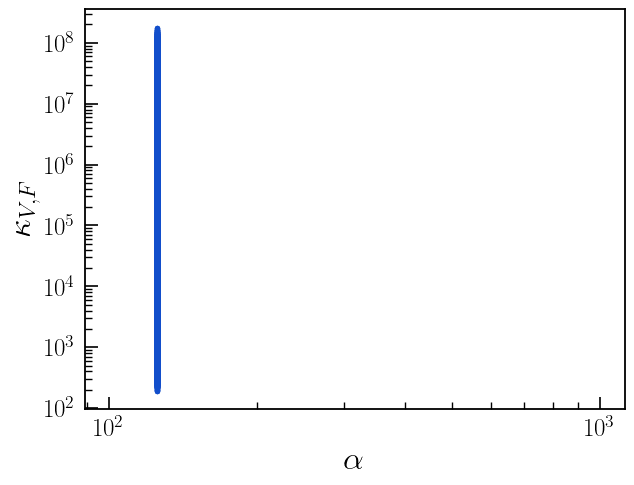

In [25]:
plt.style.use('./paper_style_colorbar.mplstyle')

fig = plt.figure(figsize=(9, 5))
ax_main = fig.add_axes([0.1, 0.1, 0.6, 0.8])
trans_xaxes_ydata = transforms.blended_transform_factory(ax_main.transAxes, ax_main.transData)

sc_main= sp_scatter(ax_main, mh, mHH, allow_cond= (kappa_F>ckw), x_lab=r'$\alpha$',
                    y_lab=r'$\kappa_{V,F}$',
                   lw=0.0)

ax_main.set_yscale("log")
ax_main.set_xscale("log")

#ax_main.set_ylim(0.5, 1.1)
#ax_main.set_xlim(-1, 1)

#plt.savefig("p4.pdf", format="pdf", dpi=300, bbox_inches="tight")
#plt.savefig("p4.png", format="png", dpi=300, bbox_inches="tight")

plt.show()